# Artificial Intelligence
## L.EIC – 3rd Year/2nd Semester
### Exercise Sheet 3
# Adversarial Search

Apply the Minimax algorithm with alpha-beta cuts to the following game tree. The evaluation function values are indicated in the leaf nodes. You should:
- compute the minimax value in each node
- identify which branches are prunned via alpha-beta cuts

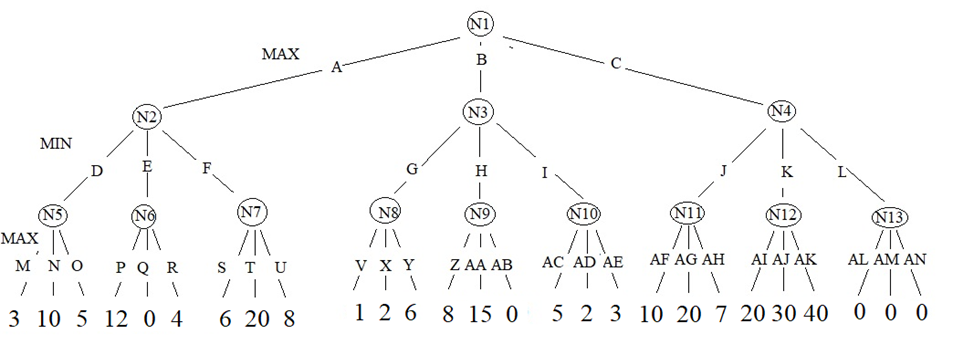

## Connect Four (“4-em-Linha”) Game using Minimax with Alpha-Beta Cuts

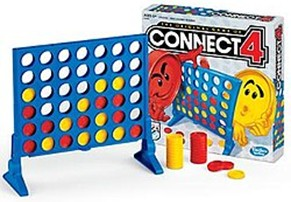

A board game is characterized by the type of board and tiles, the rules of movement of the pieces (operators/possible moves) and the finishing conditions of the game with the respective score and result.

[Connect Four](https://en.wikipedia.org/wiki/Connect_Four) is played on a vertical board of 7x6 squares (i.e., 7 squares wide and 6 squares high), by two players, to each of which 21 pieces are initially assigned (one of the players has yellow pieces and the other red pieces).

The two players play alternately one of their pieces. The piece to be played is placed on the top of the board and slides vertically to either the base of the board or to the cell immediately above the top already occupied cell. The winner is the player who manages to obtain a line with 4 of its pieces horizontally, vertically, or diagonally. If the 42 pieces are played without any player making a line, the final result will be a draw.

**a)** Formulate this game as an adversarial search problem, indicating the state representation, moves/operators (with preconditions and effects), and the objective test.

**b)** What is the state space size for the Connect Four game?

**c)** What is the maximum branching factor for the Connect Four game?

**d)** The following class implements a state in the Connect Four game. You may complete the methods as they are required for the subsequent questions. For now, complete the implementation of ``available_moves``, ``move``, and ``is_winner``.

In [ ]:
import numpy as np
import time
NUM_ROWS = 6
NUM_COLUMNS = 7


class ConnectFourState:
    
    def __init__(self):
        
        # initial board state (empty board)
        self.state = np.zeros((NUM_ROWS, NUM_COLUMNS))
        
        # players
        self.player_1 = 1   # player 1 symbol
        self.player_2 = 2   # player 2 symbol
        self.current_player = self.player_1
        
        # game status
        self.game_over = False   # track if game has ended
        self.winning_player = 0   # store the player that wins, when the game is over (0 if we have a draw)
    
    
    def __str__(self):
        return str(self.state)
    
    
    def game_draw(self):
        '''
        Checks if the game has ended with a draw.
        '''
        return self.game_over == True and self.winning_player == 0;
    
    
    def available_moves(self):
        '''
        Returns a list with the available moves (columns that are not full).
        '''
        # your code here
        
    
    
    def move(self, column):
        '''
        Implements a move of the current player for the given column.
        After the move, checks if the player has won or if the game has ended with a draw.
        '''
        
        # find the lowest empty position in the column and place piece there (current_player)
        # your code here
        
        
        
        
        
        # check if won
        if(self.is_winner(row, column)):
            self.game_over = True
            self.winning_player = self.current_player
        else:
            # check if game has ended
            if(len(self.available_moves()) == 0):   #if there are no more available moves
                self.game_over = True
                self.winning_player = 0
        
        # change players turn
        self.current_player = self.player_2 if self.current_player == self.player_1 else self.player_1
        
        return
    
    
    def is_winner(self, row, col):
        '''
        Checks if the player that played in the (row, col) position has made a 4-line (horizontally, vertically, or diagonally).
        '''
        
        player = self.state[row][col]
        
        # your code here
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        return False
    
    
    def number_of_lines_with_four_pieces(self, player):
        """
        Gets the number of lines (horizontal, vertical, diagonal) where the player has at least 4 pieces
        (not necessarily consecutive).
        """
        
        n_four_pieces_lines = 0
        
        # Horizontal check:
        for row in range(NUM_ROWS):
            if((self.state[row] == player).sum() >= 4):
                n_four_pieces_lines += 1
        
        # Vertical check:
        # your code here
        
        
        
        
        # Diagonals
        # your code here
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        return n_four_pieces_lines
    
    
    def number_of_winning_spots(self, player):
        """
        Gets the number of consecutive 4 positions in a line (horizontal, vertical, diagonal) 
        where 3 are player pieces and 1 is empty.
        """
        
        n_winning_spots = 0
        
        # Horizontal check:
        for row in range(NUM_ROWS):
            for col in range(NUM_COLUMNS-3):
                pieces = [self.state[row][col], self.state[row][col+1],
                          self.state[row][col+2], self.state[row][col+3]]
                #check if we found a 4-position sequence with 3 instances of the current player and 1 empty spot
                if pieces.count(player) == 3 and pieces.count(0) == 1:
                    n_winning_spots += 1
        
        # Vertical check:
        # your code here
        
        
        
        
        
        
        
        # Diagonal - Top-Left to Bottom-Right:
        # your code here
        
        
        
        
        
        
        
        # Diagonal - Bottom-Left to Top-Right:
        # your code here
        
        
        
        
        
        
        
        return n_winning_spots
    
    
    def central_points(self, player):
        """
        Assigns 2 points to each player piece in the center column of the board (column 4)
        and 1 point to each piece in the columns around it (columns 3 and 5).
        """
        points = 0
        # your code here
        
        
        
        
        
        
        return points

**e)** The following class implements a Connect Four game. Complete the implementation of the method ``play_game``. You should get the current player object, generate a move via ``player.get_move(self)``, and execute the move in the game.

In [ ]:
class ConnectFourGame:
    
    def __init__(self, player_1, player_2, log = True):
        '''
        The player_1 and player_2 arguments are player objects, which should have a ``get_move`` method 
        for generating a move in the game, via player.get_move(self).
        '''
        
        self.log = log
        self.players = {1: player_1, 2: player_2}   # map player numbers to objects
    
    
    def play_game(self):
        '''
        Plays one Connect Four game and returns the winner (or 0 if we have a draw).
        '''
        
        # create a new board
        self.state = ConnectFourState()
        
        # force player_1 to play first or decide randomly who starts (1 or 2)
        self.state.current_player = 1
        #self.state.current_player = np.random.choice([1, 2])
        
        while self.state.game_over == False:
            # your code here
            
            
            
            
            
            
            
            
            
            
        
        if self.state.game_draw():
            if self.log:
                print(f"\nGame over! The Game ended with a draw!")
                print(self.state.state)
            return 0
        else:
            if self.log:
                print(f"\nGame over! {self.players[self.state.winning_player].name} (Player_{self.state.winning_player}) won!")
                print(self.state.state)
            return self.state.winning_player
    
    
    def run_n_matches(self, n, log = False):
        '''
        Utility function to automate the execution of a number of matches (n).
        Prints the number of wins for each player and the number of draws.
        Prints the time each game takes to complete.
        '''
        # your code here
        
        
        
        
        
        
        
        
        
        

**f)** Implement a simple player that performs random moves.

In [ ]:
class Player:
    
    def get_move(self, game):
        # This method should be implemented by subclasses
        raise NotImplementedError("Subclasses must implement this method")


class RandomPlayer(Player):
    
    def __init__(self, name):
        self.name = name
    
    def get_move(self, game):
        '''
        Returns a random move.
        '''
        # your code here
        
        
        

Test your implementation by running games with two random agents.

In [ ]:
random_player_1 = RandomPlayer(name = 'random_1')
random_player_2 = RandomPlayer(name = 'random_2')
game = ConnectFourGame(random_player_1, random_player_2, log=True)
game.play_game()

**g)** Implement a human player that requests moves to the user.

In [ ]:
class HumanPlayer(Player):
    
    def __init__(self,name):
        self.name = name
    
    def get_move(self, game):
        '''
        Returns a move as chosen by the user. The user choice is validated to ensure it is an available move.
        '''
        # your code here
        
        
        
        
        
        
        
        
        
        
        
        

Test your implementation by running games with one human player and a random agent.

In [ ]:
human_player_1 = HumanPlayer(name = 'human_player_1')
game = ConnectFourGame(human_player_1, random_player_2, log=True)
game.play_game()

**h)** In the ConnectFourState class, implement the methods ``number_of_lines_with_four_pieces``, ``number_of_winning_spots``, and ``central_points``.
Define the following state evaluation functions:
> ``eval1 = number_of_lines_with_four_pieces(player) - number_of_lines_with_four_pieces(opponent)``:  
> ``eval2 = 100 * eval1 + number_of_winning_spots(player) - number_of_winning_spots(opponent)``  
> ``eval3 = 100 * eval1 + central_points(player) - central_points(opponent)``  
> ``eval4 = 5 * eval2 + eval3``

In [ ]:
def eval_game_over(game_state, player):
    if game_state.game_over:
        if game_state.winning_player == 0:
            return 0
        else:
            if game_state.winning_player == player:
                return 1000
            else: return -1000
    else: return 0

def eval1(game_state, player):
    if game_state.game_over:
        return eval_game_over(game_state, player)
    
    # your code here
    
    

def eval2(game_state, player):
    if game_state.game_over:
        return eval_game_over(game_state, player)
    
    # your code here
    
    

def eval3(game_state, player):
    if game_state.game_over:
        return eval_game_over(game_state, player)
    
    # your code here
    
    

def eval4(game_state, player):
    if game_state.game_over:
        return eval_game_over(game_state, player)
    
    # your code here
    
    

**i)** Implement a more complex player to play the game using the Minimax algorithm with alpha-beta cuts.

In [ ]:
import copy

class MinimaxPlayer(Player):
    
    def __init__(self, name, eval_func, depth):
        self.name = name
        self.eval_func = eval_func
        self.depth = depth
    
    
    def _simulate_move(self, game_state, column):
        """Create a copy of game_state with the move applied"""
        
        new_state = copy.deepcopy(game_state)
        new_state.move(column)
        return new_state
    
    
    def get_move(self, game):
        """Find the best move using the Minimax alpha-beta algorithm"""
        
        move = self.minimax_alpha_beta_search(game)
        return move
    
    
    def minimax_alpha_beta_search(self, game):
        '''
        Returns the move with the best minimax value.
        '''
        
        player = game.state.current_player
        _, move = self.max_value(game.state, self.depth, float('-inf'), float('inf'), player)
        return move
    
    
    def max_value(self, state, depth, alpha, beta, original_player):
        '''
        Returns the evaluation and the move with the max minimax value.
        '''
        
        if depth == 0 or state.game_over:
            # Evaluate always from the perspective of the AI that started the search
            return self.eval_func(state, original_player), None
        
        # your code here
        
        
        
        
        
        
        
        
        
        
        
    
    
    def min_value(self, state, depth, alpha, beta, original_player):
        '''
        Returns the evaluation and the move with the min minimax value.
        '''
        
        # your code here
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        

Test your Minimax agent. You can run games with two Minimax players, with different evaluation functions and/or depths. Analyse the results.

In [ ]:
# your code here





**j)** Run several matches between different agents and analyse the results (you need to implement method ``run_n_matches`` in ``ConnectFourGame``).

In [ ]:
# your code here
